<a href="https://colab.research.google.com/github/SamsrithM/BasePaperIMP/blob/main/phase-1_finalyear_proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#How to run

1. Import libraries

2. Mount Google Drive

3. Load dataset

4. Create data loaders

5. Define EarlyExit class

6. Define EarlyExitCNN class

7. Initialize the model

8. Define loss function

9. Define optimizer

10. Train the CNN

11. Save the trained model

12. Apply pruning

13. Fine-tune the pruned model

14. Save the 10%, 30%, and 50% models

15. Create the DynamicSplitModel

16. Create the DecisionEngine

17. Load the selected pruned model

18. Simulate runtime conditions
   - battery
   - bandwidth
   - CPU usage

19. Execute the decision engine

20. Display the result

<h2>load the model<br>
way:<br>
Imports,Device,EarlyExit class,EarlyExitCNN class,Mount Google Drive,Load the checkpoint

#cnn and early exit

In [1]:
#Install & Import Libraries
import torch
import torch.nn as nn
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader
from torchvision.datasets import CIFAR10

import torch.optim as optim

from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
from google.colab import drive
import zipfile
import os


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [2]:
drive.mount('/content/drive')

zip_path = "/content/drive/MyDrive/final year project/datasets/cifer10.zip"

extract_path = "/content/dataset"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Mounted at /content/drive
Dataset extracted successfully!


In [3]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    )
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    )
])


In [4]:
import os

for root, dirs, files in os.walk("/content/dataset"):
    print(root)


/content/dataset
/content/dataset/cifar10
/content/dataset/cifar10/train
/content/dataset/cifar10/train/dog
/content/dataset/cifar10/train/automobile
/content/dataset/cifar10/train/frog
/content/dataset/cifar10/train/cat
/content/dataset/cifar10/train/bird
/content/dataset/cifar10/train/horse
/content/dataset/cifar10/train/truck
/content/dataset/cifar10/train/deer
/content/dataset/cifar10/train/ship
/content/dataset/cifar10/train/airplane
/content/dataset/cifar10/test
/content/dataset/cifar10/test/dog
/content/dataset/cifar10/test/automobile
/content/dataset/cifar10/test/frog
/content/dataset/cifar10/test/cat
/content/dataset/cifar10/test/bird
/content/dataset/cifar10/test/horse
/content/dataset/cifar10/test/truck
/content/dataset/cifar10/test/deer
/content/dataset/cifar10/test/ship
/content/dataset/cifar10/test/airplane


In [5]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

train_dataset = ImageFolder(
    root="/content/dataset/cifar10/train",
    transform=transform_train
)

test_dataset = ImageFolder(
    root="/content/dataset/cifar10/test",
    transform=transform_test
)

In [6]:
train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

classes = train_dataset.classes

print("Classes:", classes)
print("Training Images:", len(train_dataset))
print("Testing Images:", len(test_dataset))

Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Training Images: 50000
Testing Images: 10000


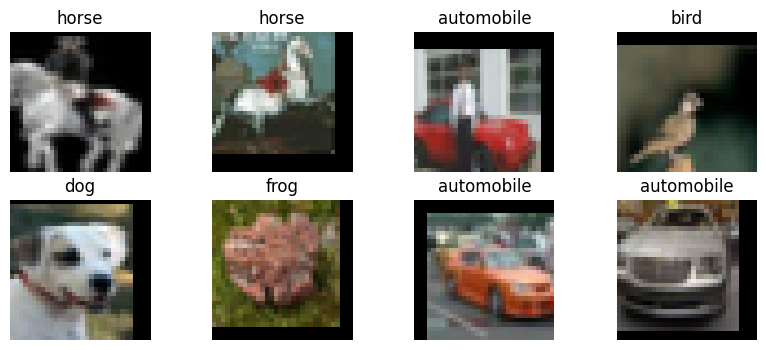

In [7]:
#Visualize the Dataset
images, labels = next(iter(train_loader))

plt.figure(figsize=(10,4))

for i in range(8):
    plt.subplot(2,4,i+1)
    img = images[i].permute(1,2,0)

    img = img * torch.tensor((0.2023,0.1994,0.2010)) + \
          torch.tensor((0.4914,0.4822,0.4465))

    plt.imshow(img)
    plt.title(classes[labels[i]])
    plt.axis("off")

plt.show()

In [8]:
#Create the Early Exit Module
class EarlyExit(nn.Module):

    def __init__(self, in_channels, num_classes=10):

        super().__init__()

        self.conv = nn.Conv2d(
            in_channels,
            in_channels,
            kernel_size=3,
            padding=1
        )

        self.pool = nn.AdaptiveMaxPool2d((1,1))

        self.fc1 = nn.Linear(in_channels,128)
        self.fc2 = nn.Linear(128,num_classes)

    def forward(self,x):

        x = F.relu(self.conv(x))

        x = self.pool(x)

        x = x.view(x.size(0),-1)

        x = F.relu(self.fc1(x))

        return self.fc2(x)

In [9]:
#Build the Main CNN Architecture
class EarlyExitCNN(nn.Module):

    def __init__(self,num_classes=10):

        super().__init__()

        self.conv1 = nn.Conv2d(3,32,3,padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32,64,3,padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64,128,3,padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.conv4 = nn.Conv2d(128,128,3,padding=1)
        self.bn4 = nn.BatchNorm2d(128)

        self.conv5 = nn.Conv2d(128,256,3,padding=1)
        self.bn5 = nn.BatchNorm2d(256)

        self.conv6 = nn.Conv2d(256,256,3,padding=1)
        self.bn6 = nn.BatchNorm2d(256)

        self.pool = nn.MaxPool2d(2,2)

        self.exit1 = EarlyExit(64,num_classes)

        self.exit2 = EarlyExit(128,num_classes)

        self.avgpool = nn.AdaptiveAvgPool2d((1,1))

        self.fc1 = nn.Linear(256,256)
        self.fc2 = nn.Linear(256,128)
        self.fc3 = nn.Linear(128,num_classes)

    def forward(self,x):

        x = self.pool(F.relu(self.bn1(self.conv1(x))))

        x = self.pool(F.relu(self.bn2(self.conv2(x))))

        out1 = self.exit1(x)

        x = F.relu(self.bn3(self.conv3(x)))

        x = self.pool(F.relu(self.bn4(self.conv4(x))))

        out2 = self.exit2(x)

        x = F.relu(self.bn5(self.conv5(x)))

        x = self.pool(F.relu(self.bn6(self.conv6(x))))

        x = self.avgpool(x)

        x = torch.flatten(x,1)

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))

        out3 = self.fc3(x)

        return out1,out2,out3

In [10]:
#Create the Model
model = EarlyExitCNN().to(device)

print(model)

EarlyExitCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv5): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn5): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv6): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_

In [11]:
#Define Loss Function and Optimizer
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=5e-4
)

w1 = 0.3
w2 = 0.3
w3 = 1.0

In [ ]:
#Training Loop
epochs = 20

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for images,labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        exit1,exit2,final = model(images)

        loss1 = criterion(exit1,labels)
        loss2 = criterion(exit2,labels)
        loss3 = criterion(final,labels)

        loss = w1*loss1 + w2*loss2 + w3*loss3

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch {epoch+1}/{epochs}, Loss = {running_loss/len(train_loader):.4f}"
    )

Epoch 1/20, Loss = 2.2476
Epoch 2/20, Loss = 1.6205
Epoch 3/20, Loss = 1.3688
Epoch 4/20, Loss = 1.2282
Epoch 5/20, Loss = 1.1348
Epoch 6/20, Loss = 1.0598
Epoch 7/20, Loss = 0.9997
Epoch 8/20, Loss = 0.9545
Epoch 9/20, Loss = 0.9163
Epoch 10/20, Loss = 0.8734
Epoch 11/20, Loss = 0.8455
Epoch 12/20, Loss = 0.8214
Epoch 13/20, Loss = 0.7941
Epoch 14/20, Loss = 0.7787
Epoch 15/20, Loss = 0.7519
Epoch 16/20, Loss = 0.7333
Epoch 17/20, Loss = 0.7149
Epoch 18/20, Loss = 0.7056
Epoch 19/20, Loss = 0.6946
Epoch 20/20, Loss = 0.6737


In [14]:
#Test Accuracy
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images,labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        _,_,outputs = model(images)

        _,predicted = torch.max(outputs,1)

        total += labels.size(0)
        correct += (predicted==labels).sum().item()

print(f"Test Accuracy: {100*correct/total:.2f}%")

Test Accuracy: 82.43%


In [15]:
#Early Exit Inference
threshold = 0.90

model.eval()

image,label = test_dataset[55]

image = image.unsqueeze(0).to(device)

with torch.no_grad():

    e1,e2,final = model(image)

    p1 = torch.softmax(e1,1)

    if p1.max() > threshold:
        print("Prediction:", p1.argmax(1).item())
        print("Exited at Exit 1")

    else:

        p2 = torch.softmax(e2,1)

        if p2.max() > threshold:

            print("Prediction:", p2.argmax(1).item())
            print("Exited at Exit 2")

        else:

            pf = torch.softmax(final,1)

            print("Prediction:", pf.argmax(1).item())
            print("Exited at Final Output")

Prediction: 0
Exited at Exit 2


Saving to the drive


#saving the model

In [ ]:
save_dir = "/content/drive/MyDrive/final year project/models"
os.makedirs(save_dir, exist_ok=True)

save_path = "/content/drive/MyDrive/final year project/models/cnn_checkpoint.pth"

torch.save(
    {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "model_name": "EarlyExitCNN"
    },
    save_path
)

print("Model saved successfully!")

Model saved successfully!


#loading the model

In [13]:
checkpoint = torch.load(
    "/content/drive/MyDrive/final year project/models/cnn_checkpoint.pth",
    map_location=device
)

model = EarlyExitCNN().to(device)

model.load_state_dict(checkpoint["model_state_dict"])

model.eval()

print("Model loaded successfully!")

Model loaded successfully!


#If you want to continue training

In [ ]:
optimizer = torch.optim.Adam(model.parameters())

optimizer.load_state_dict(
    checkpoint["optimizer_state_dict"]
)

starting_epoch = checkpoint["epoch"]



---



---
#start of the pruning model



In [ ]:
import torch.nn.utils.prune as prune

In [ ]:
def prune_conv_layers(model, amount=0.30):

    conv_layers = [
        model.conv1,
        model.conv2,
        model.conv3,
        model.conv4,
        model.conv5,
        model.conv6,
        model.exit1.conv,
        model.exit2.conv
    ]

    for layer in conv_layers:

        prune.ln_structured(
            layer,
            name="weight",
            amount=amount,
            n=1,
            dim=0
        )

        prune.remove(layer, "weight")

    print("Pruning completed.")

In [ ]:
prune_conv_layers(model, amount=0.30)

Pruning completed.


In [ ]:
total_parameters = 0
remaining_parameters = 0

for parameter in model.parameters():

    total_parameters += parameter.numel()

    remaining_parameters += torch.count_nonzero(
        parameter
    ).item()

compression = (
    1 - remaining_parameters / total_parameters
) * 100

print("Total parameters:", total_parameters)
print("Remaining parameters:", remaining_parameters)
print("Compression ratio:", compression)

Total parameters: 1439710
Remaining parameters: 1047472
Compression ratio: 27.244236686554935


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001
)

epochs = 5

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        out1, out2, out3 = model(images)

        loss1 = criterion(out1, labels)
        loss2 = criterion(out2, labels)
        loss3 = criterion(out3, labels)

        total_loss = (
            0.3 * loss1 +
            0.3 * loss2 +
            0.4 * loss3
        )

        total_loss.backward()

        optimizer.step()

        running_loss += total_loss.item()

    print(
        f"Epoch {epoch+1}, Loss = {running_loss:.4f}"
    )

Epoch 1, Loss = 223.6971
Epoch 2, Loss = 187.1420
Epoch 3, Loss = 178.5457
Epoch 4, Loss = 170.6889
Epoch 5, Loss = 166.4674


In [ ]:
save_path = (
    "/content/drive/MyDrive/final year project/models/"
    "pruned_model.pth"
)

torch.save(model.state_dict(), save_path)

print("Model saved successfully.")

Model saved successfully.


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

loaded_pruned_model = EarlyExitCNN().to(device)

save_path = (
    "/content/drive/MyDrive/final year project/models/"
    "pruned_model.pth"
)

loaded_pruned_model.load_state_dict(torch.load(save_path, map_location=device))

loaded_pruned_model.eval()

print("Pruned model loaded successfully!")

Pruned model loaded successfully!


---
#Pruning with different leveles

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = EarlyExitCNN().to(device)

model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/final year project/models/cnn_model.pth",
        map_location=device
    )
)

model.eval()

EarlyExitCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv5): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn5): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv6): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_

In [17]:
#imoprts
import copy
import torch.nn.utils.prune as prune

In [18]:
#pruning function
def apply_pruning(model, amount):

    pruned_model = copy.deepcopy(model)

    conv_layers = [
        pruned_model.conv1,
        pruned_model.conv2,
        pruned_model.conv3,
        pruned_model.conv4,
        pruned_model.conv5,
        pruned_model.conv6,
        pruned_model.exit1.conv,
        pruned_model.exit2.conv
    ]

    for layer in conv_layers:

        prune.ln_structured(
            layer,
            name="weight",
            amount=amount,
            n=1,
            dim=0
        )

        prune.remove(layer, "weight")

    return pruned_model

In [19]:
#calculate sparsity
def calculate_sparsity(model):

    total = 0
    remaining = 0

    for parameter in model.parameters():

        total += parameter.numel()

        remaining += torch.count_nonzero(
            parameter
        ).item()

    sparsity = 100 * (1 - remaining / total)

    return sparsity

In [20]:
#fine-tuning function
criterion = nn.CrossEntropyLoss()


def fine_tune(model, train_loader, epochs=3):

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.0001
    )

    model.train()

    for epoch in range(epochs):

        running_loss = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            out1, out2, out3 = model(images)

            loss1 = criterion(out1, labels)
            loss2 = criterion(out2, labels)
            loss3 = criterion(out3, labels)

            total_loss = (
                0.3 * loss1
                + 0.3 * loss2
                + 0.4 * loss3
            )

            total_loss.backward()

            optimizer.step()

            running_loss += total_loss.item()

        print(
            f"Epoch {epoch + 1}: "
            f"{running_loss:.4f}"
        )

    return model

In [21]:
#generate three models
pruning_levels = [0.10, 0.30, 0.50]

for level in pruning_levels:

    print(f"\nPruning {int(level * 100)}%")

    pruned_model = apply_pruning(model, level)

    fine_tune(
        pruned_model,
        train_loader,
        epochs=3
    )

    sparsity = calculate_sparsity(pruned_model)

    print(f"Sparsity = {sparsity:.2f}%")

    save_path = (
        f"/content/drive/MyDrive/final year project/"
        f"models/cnn_pruned_{int(level*100)}.pth"
    )

    torch.save(
        pruned_model.state_dict(),
        save_path
    )

    print("Saved:", save_path)


Pruning 10%
Epoch 1: 156.1220
Epoch 2: 143.5695
Epoch 3: 136.9205
Sparsity = 9.21%
Saved: /content/drive/MyDrive/final year project/models/cnn_pruned_10.pth

Pruning 30%
Epoch 1: 234.9781
Epoch 2: 190.2803
Epoch 3: 177.8698
Sparsity = 26.99%
Saved: /content/drive/MyDrive/final year project/models/cnn_pruned_30.pth

Pruning 50%
Epoch 1: 402.8826
Epoch 2: 289.0670
Epoch 3: 260.3802
Sparsity = 44.78%
Saved: /content/drive/MyDrive/final year project/models/cnn_pruned_50.pth


In [22]:
def load_pruned_model(level):

    model = EarlyExitCNN().to(device)

    path = (
        f"/content/drive/MyDrive/final year project/"
        f"models/cnn_pruned_{level}.pth"
    )

    model.load_state_dict(
        torch.load(path, map_location=device)
    )

    model.eval()

    print(f"{level}% pruned model loaded.")

    return model

pruned_10 = load_pruned_model(10)
pruned_30 = load_pruned_model(30)
pruned_50 = load_pruned_model(50)

10% pruned model loaded.
30% pruned model loaded.
50% pruned model loaded.


#Spliting starts here

<h2>dynamic split model<h2>

In [23]:
SPLIT_EXIT1 = 1
SPLIT_EXIT2 = 2
SPLIT_CLOUD = 3
SPLIT_EDGE = 4

In [24]:
class DynamicSplitModel(nn.Module):

    def __init__(self, model):

        super().__init__()

        self.model = model

    def forward(self, x, split_point):

        # -------------------------
        # Conv1
        # -------------------------

        x = self.model.pool(
            F.relu(
                self.model.bn1(
                    self.model.conv1(x)
                )
            )
        )

        # -------------------------
        # Conv2
        # -------------------------

        x = self.model.pool(
            F.relu(
                self.model.bn2(
                    self.model.conv2(x)
                )
            )
        )

        out1 = self.model.exit1(x)

        # ==================================================
        # Split after exit 1
        # ==================================================

        if split_point == SPLIT_EXIT1:

            return {
                "split": "exit1",
                "feature_map": x,
                "exit_output": out1
            }

        # -------------------------
        # Conv3
        # -------------------------

        x = F.relu(
            self.model.bn3(
                self.model.conv3(x)
            )
        )

        # -------------------------
        # Conv4
        # -------------------------

        x = self.model.pool(
            F.relu(
                self.model.bn4(
                    self.model.conv4(x)
                )
            )
        )

        out2 = self.model.exit2(x)

        # ==================================================
        # Split after exit 2
        # ==================================================

        if split_point == SPLIT_EXIT2:

            return {
                "split": "exit2",
                "feature_map": x,
                "exit_output": out2
            }

        # -------------------------
        # Conv5
        # -------------------------

        x = F.relu(
            self.model.bn5(
                self.model.conv5(x)
            )
        )

        # -------------------------
        # Conv6
        # -------------------------

        x = self.model.pool(
            F.relu(
                self.model.bn6(
                    self.model.conv6(x)
                )
            )
        )

        x = self.model.avgpool(x)

        x = torch.flatten(x, 1)

        x = F.relu(self.model.fc1(x))
        x = F.relu(self.model.fc2(x))

        out3 = self.model.fc3(x)

        return {
            "split": "final",
            "output": out3
        }

In [25]:
model = EarlyExitCNN()

path = (
    "/content/drive/MyDrive/final year project/"
    "models/cnn_pruned_30.pth"
)

model.load_state_dict(torch.load(path))

model.eval()

EarlyExitCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv5): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn5): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv6): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_

In [80]:
dynamic_model = DynamicSplitModel(model)
result = dynamic_model(images, SPLIT_EXIT2)
print(result["split"])

RuntimeError: Input type (torch.cuda.FloatTensor) and weight type (torch.FloatTensor) should be the same

<h2>decision engine<h2>

In [27]:
PRUNE_10 = 10
PRUNE_30 = 30
PRUNE_50 = 50

EXIT_1 = 1
EXIT_2 = 2

FULL_EDGE = 3
FULL_CLOUD = 4

In [28]:
class DecisionEngine:

    def __init__(self):

        self.bandwidth_threshold = 5.0
        self.battery_threshold = 30.0
        self.cpu_threshold = 80.0

        self.exit1_threshold = 0.95
        self.exit2_threshold = 0.90

    def choose_pruning(self, battery):

        if battery < 20:
            return PRUNE_50

        elif battery < 50:
            return PRUNE_30

        return PRUNE_10

    def choose_split(self, bandwidth, cpu_usage):

        if bandwidth < self.bandwidth_threshold:
            return FULL_EDGE

        elif cpu_usage > self.cpu_threshold:
            return FULL_CLOUD

        return EXIT_2

    def choose_early_exit(
            self,
            exit1_confidence,
            exit2_confidence):

        if exit1_confidence >= self.exit1_threshold:
            return EXIT_1

        elif exit2_confidence >= self.exit2_threshold:
            return EXIT_2

        return None

In [54]:
def calculate_confidence(output):

    probabilities = torch.softmax(output, dim=1)

    confidence, _ = torch.max(probabilities, dim=1)

    return confidence.item()

In [55]:
engine = DecisionEngine()

In [81]:
# replace this with the real values from the virtual created
bandwidth = 4.7
battery = 44
cpu_usage = 52

In [63]:
pruning_level = engine.choose_pruning(battery)

print(pruning_level)

30


In [64]:
split_choice = engine.choose_split(
    bandwidth,
    cpu_usage
)

print(split_choice)

3


In [65]:
exit1_confidence = 0.97
exit2_confidence = 0.92

In [66]:
exit_choice = engine.choose_early_exit(
    exit1_confidence,
    exit2_confidence
)

print(exit_choice)

1


In [67]:
print("\n===== DECISION REPORT =====")

print("Pruning level :", pruning_level)
print("Split point   :", split_choice)
print("Early exit    :", exit_choice)


===== DECISION REPORT =====
Pruning level : 30
Split point   : 3
Early exit    : 1


#Running the entire model Completely

In [37]:
#Store the model paths
MODEL_PATHS = {
    10: "/content/drive/MyDrive/final year project/models/cnn_pruned_10.pth",
    30: "/content/drive/MyDrive/final year project/models/cnn_pruned_30.pth",
    50: "/content/drive/MyDrive/final year project/models/cnn_pruned_50.pth"
}

In [38]:
#Load the selected model
def load_selected_model(pruning_level):

    model = EarlyExitCNN()

    model.load_state_dict(
        torch.load(
            MODEL_PATHS[pruning_level],
            map_location=device
        )
    )

    model.eval()

    return model

In [39]:
#Create the decision engine
engine = DecisionEngine()

In [100]:
#Obtain the runtime conditions
battery = 44
bandwidth = 4.7
cpu_usage = 52

In [101]:
#Choose the pruning level
pruning_level = engine.choose_pruning(battery)

print(pruning_level)

30


In [102]:
#Load the corresponding model
selected_model = load_selected_model(pruning_level)

In [103]:
import torch.nn.functional as F

with torch.no_grad():

    selected_model.to(device) # Ensure the model is on the correct device

    single_image, _ = test_dataset[0] # Get the first image from the test dataset
    images_for_inference = single_image.unsqueeze(0) # Add a batch dimension

    x = images_for_inference.to(device)

    x = selected_model.pool(
        F.relu(
            selected_model.bn1(
                selected_model.conv1(x)
            )
        )
    )

    x = selected_model.pool(
        F.relu(
            selected_model.bn2(
                selected_model.conv2(x)
            )
        )
    )

    exit1_output = selected_model.exit1(x)

In [104]:
#Calculate the confidence score
exit1_confidence = calculate_confidence(
    exit1_output
)

In [105]:
#Obtain the split decision
split_choice = engine.choose_split(
    bandwidth,
    cpu_usage
)

In [106]:
#Obtain the early-exit decision
exit_choice = engine.choose_early_exit(
    exit1_confidence,
    0
)

In [107]:
#Display the final report
print("\n==============================")
print("DYNAMIC INFERENCE REPORT")
print("==============================")

print(f"Battery level     : {battery}%")
print(f"Bandwidth         : {bandwidth} Mbps")
print(f"CPU usage         : {cpu_usage}%")

print()

print(f"Selected pruning  : {pruning_level}%")
print(f"Selected split    : {split_choice}")
print(f"Selected exit     : {exit_choice}")


DYNAMIC INFERENCE REPORT
Battery level     : 44%
Bandwidth         : 4.7 Mbps
CPU usage         : 52%

Selected pruning  : 30%
Selected split    : 3
Selected exit     : None


In [108]:
def display_result(pruning, split_choice):

    print("\n========== DECISION REPORT ==========\n")

    print(f"Selected pruning level : {pruning}%")

    if split_choice == EXIT_1:

        print("Split location         : Exit 1")
        print("Edge execution         : Conv1 → Conv2")
        print("Cloud execution        : Conv3 → FC3")

    elif split_choice == EXIT_2:

        print("Split location         : Exit 2")
        print("Edge execution         : Conv1 → Conv4")
        print("Cloud execution        : Conv5 → FC3")

    elif split_choice == FULL_EDGE:

        print("Execution mode         : Entirely on edge")

    else:

        print("Execution mode         : Entirely on cloud")

In [109]:
display_result(pruning_level, split_choice)


========== DECISION REPORT ==========

Selected pruning level : 30%
Execution mode         : Entirely on edge
